In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

dfs = []
for i in range(1, 7):
    path = f'd.csv'
    dfs.append(pd.read_csv(path, encoding='latin-1', delimiter=','))
    

In [2]:
print(dfs)

[                  timestamp  temperature_C
0       2025-01-01 00:00:00      30.397371
1       2025-01-01 00:00:18      29.894843
2       2025-01-01 00:00:36      30.529059
3       2025-01-01 00:00:54      31.234786
4       2025-01-01 00:01:12      29.834494
...                     ...            ...
143995  2025-01-30 23:58:30            NaN
143996  2025-01-30 23:58:48            NaN
143997  2025-01-30 23:59:06            NaN
143998  2025-01-30 23:59:24            NaN
143999  2025-01-30 23:59:42            NaN

[144000 rows x 2 columns],                   timestamp  temperature_C
0       2025-01-01 00:00:00      30.397371
1       2025-01-01 00:00:18      29.894843
2       2025-01-01 00:00:36      30.529059
3       2025-01-01 00:00:54      31.234786
4       2025-01-01 00:01:12      29.834494
...                     ...            ...
143995  2025-01-30 23:58:30            NaN
143996  2025-01-30 23:58:48            NaN
143997  2025-01-30 23:59:06            NaN
143998  2025-01-30 23:59:

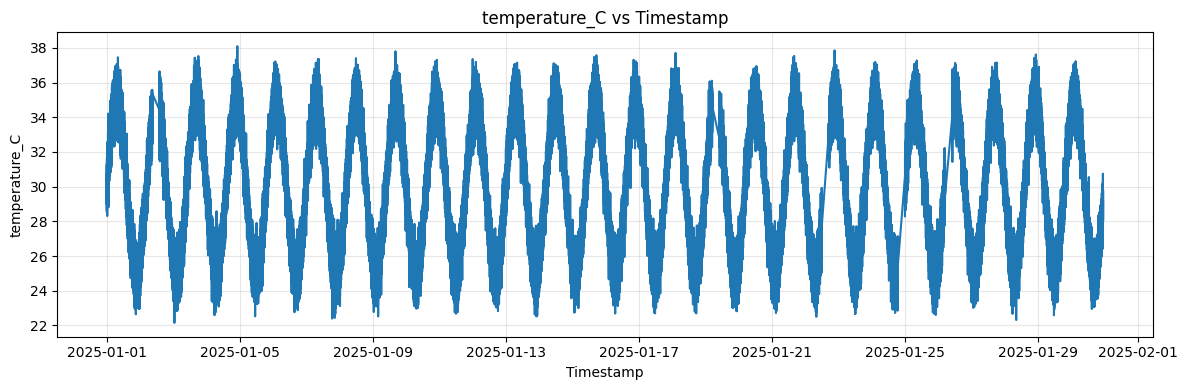

In [8]:
# ...existing code...
import matplotlib.pyplot as plt

df = pd.concat(dfs, ignore_index=True)
temp = [c for c in df.columns if 'temperature' in c.lower()][0]
time = [c for c in df.columns if 'date' in c.lower() or 'time' in c.lower()][0]

df[time] = pd.to_datetime(df[time], errors='coerce')
df[temp] = pd.to_numeric(df[temp], errors='coerce')
df = df.dropna(subset=[time, temp]).sort_values(time).set_index(time)

plt.figure(figsize=(12,4))
plt.plot(df.index, df[temp])
plt.xlabel('Timestamp'); plt.ylabel(temp); plt.title(f'{temp} vs Timestamp')
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
# ...existing code...

In [16]:

df['lag_1'] = df['temperature_C'].shift(1)
df['lag_48'] = df['temperature_C'].shift(48)
df['lag_96'] = df['temperature_C'].shift(96)

df = df.dropna(subset=['lag_1', 'lag_48', 'lag_96'])

def create_features(df, label=None):
  df['date']=df.index
  df['hour']=df['date'].dt.hour
  df['dayofweek'] = df['date'].dt.dayofweek
  df['month'] = df['date'].dt.month
  df['year'] = df['date'].dt.year
  df['dayofyear'] = df['date'].dt.dayofyear
  df['dayofmonth'] = df['date'].dt.day

  X = df[['hour','dayofweek','month','year','dayofyear','dayofmonth','lag_1', 'lag_48', 'lag_96']]

  if label:
    y = df[label]
    return X, y
  return X
X, y = create_features(df, label='temperature_C')

# Train-test split
split_date = '2025-01-25 00:00:00'
train, test = df.iloc[df.index < split_date].copy(), df.iloc[df.index >= split_date].copy()

X_train, y_train = create_features(train, label='temperature_C')
X_test, y_test = create_features(test, label='temperature_C')

C:\Users\alaed\AppData\Local\Temp\ipykernel_25452\306806864.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['date']=df.index
C:\Users\alaed\AppData\Local\Temp\ipykernel_25452\306806864.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['hour']=df['date'].dt.hour
C:\Users\alaed\AppData\Local\Temp\ipykernel_25452\306806864.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the

In [17]:
print(df.head())

                     temperature_C      lag_1     lag_48     lag_96  \
timestamp                                                             
2025-01-01 00:04:48      29.276998  29.631979  29.668053  30.397371   
2025-01-01 00:04:48      29.276998  29.276998  29.668053  30.397371   
2025-01-01 00:04:48      29.276998  29.276998  29.668053  30.397371   
2025-01-01 00:04:48      29.276998  29.276998  29.668053  30.397371   
2025-01-01 00:04:48      29.276998  29.276998  29.668053  30.397371   

                                   date  hour  dayofweek  month  year  \
timestamp                                                               
2025-01-01 00:04:48 2025-01-01 00:04:48     0          2      1  2025   
2025-01-01 00:04:48 2025-01-01 00:04:48     0          2      1  2025   
2025-01-01 00:04:48 2025-01-01 00:04:48     0          2      1  2025   
2025-01-01 00:04:48 2025-01-01 00:04:48     0          2      1  2025   
2025-01-01 00:04:48 2025-01-01 00:04:48     0          2      1 

In [18]:
import xgboost as xgb
from sklearn.metrics import r2_score

reg = xgb.XGBRegressor(n_estimators=450,
                       max_depth=7,
                       learning_rate=0.09714204214783101,
                       subsample=0.676595687559066,
                       colsample_bytree=0.939401299350375,
                       gamma=1.2862151889256177,
                       eval_metric="rmse")
reg.fit(X_train,y_train,
       eval_set=[(X_train, y_train), (X_test, y_test)],
       verbose=False)
y_pred = reg.predict(X_test)
print( r2_score(y_test, y_pred) )

0.9844458345391133


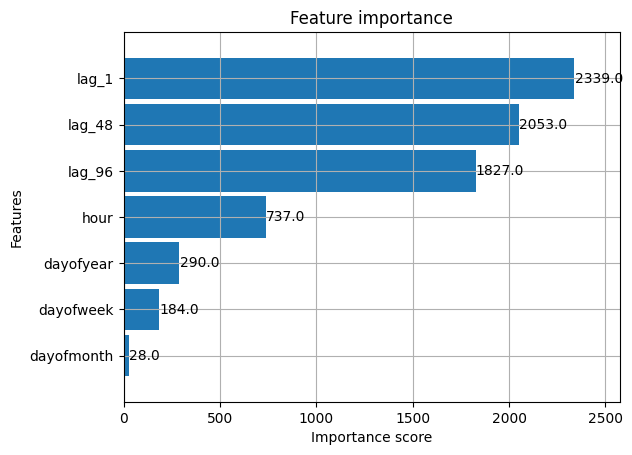

In [19]:
from xgboost import plot_importance, plot_tree

_ = plot_importance(reg, height=0.9)

In [20]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5

def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mean_absolute_percentage_error(y_test, y_pred)}%")
print(f"R²: {r2_score(y_test, y_pred)}")

MSE: 0.20806805458655644
RMSE: 0.45614477371395634
MAPE: 0.8016572887290725%
R²: 0.9844458345391133


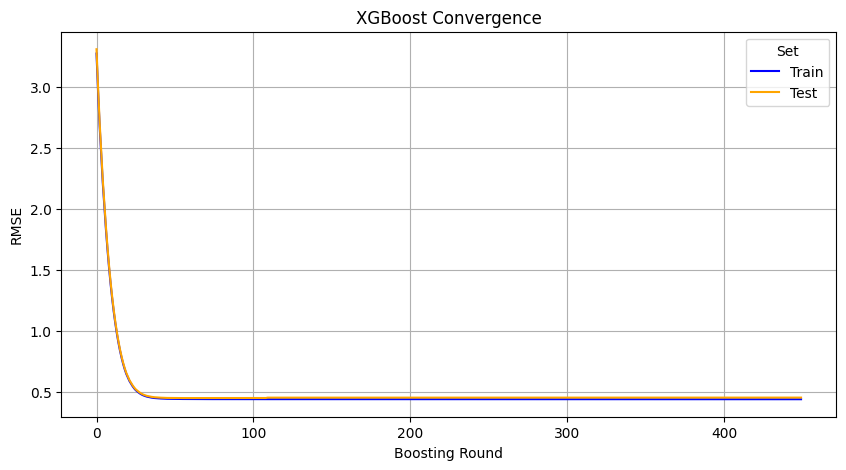

In [22]:
import matplotlib.pyplot as plt
results = reg.evals_result()

epochs = len(results['validation_0']['rmse'])
x_axis = range(0, epochs)

df_rmse = pd.DataFrame({
    "Boosting Round": list(x_axis) * 2,
    "RMSE": results['validation_0']['rmse'] + results['validation_1']['rmse'],
    "Set": ["Train"] * len(x_axis) + ["Test"] * len(x_axis)
})

plt.figure(figsize=(10, 5))
sns.lineplot(data=df_rmse, x="Boosting Round", y="RMSE", hue="Set", palette=["blue", "orange"])
plt.title("XGBoost Convergence")
plt.xlabel("Boosting Round")
plt.ylabel("RMSE")
plt.grid(True)
plt.show()

C:\Users\alaed\AppData\Local\Temp\ipykernel_25452\306806864.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['date']=df.index
C:\Users\alaed\AppData\Local\Temp\ipykernel_25452\306806864.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['hour']=df['date'].dt.hour
C:\Users\alaed\AppData\Local\Temp\ipykernel_25452\306806864.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the

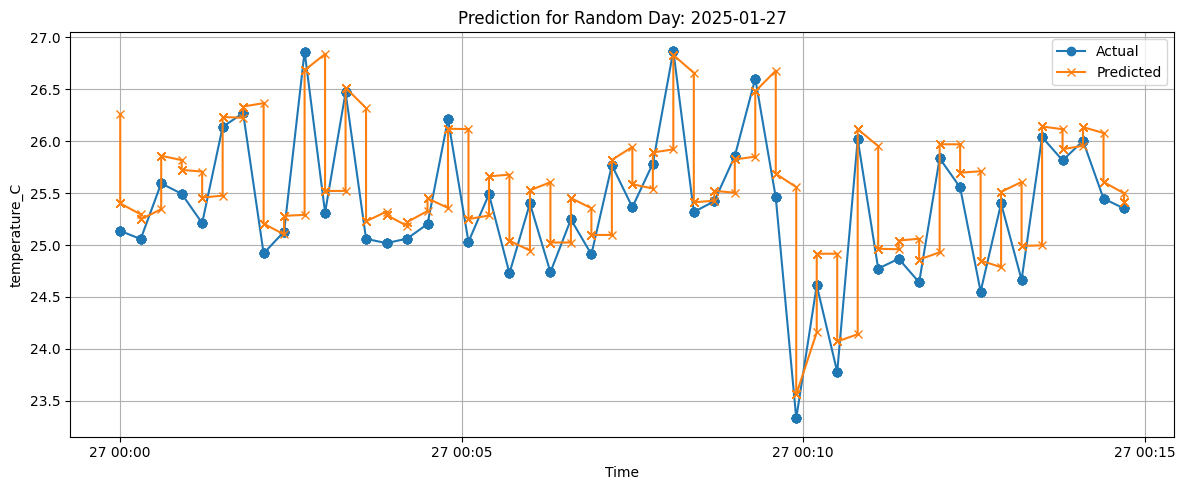

In [34]:
import random

# Keep only rows starting at midnight
midnights = df.between_time("00:00:00", "00:00:00")

# Pick a random starting date
random_start_date = random.choice(midnights.index)
start_idx = df.index.get_indexer_for([random_start_date])[0]
end_idx = start_idx + 300
random_day_df = df.iloc[start_idx:end_idx]

# Get the target window (random day)
random_day_df = df.iloc[start_idx:end_idx]

# Prepare features
X_day, y_day = create_features(random_day_df, label='temperature_C')

# Predict using your trained model
y_pred_day = reg.predict(X_day)

# Compare predictions vs actual
plt.figure(figsize=(12, 5))
plt.plot(y_day.index, y_day.values, label='Actual', marker='o')
plt.plot(y_day.index, y_pred_day, label='Predicted', marker='x')
plt.xlabel('Time')
plt.ylabel('temperature_C')
plt.title(f"Prediction for Random Day: {random_start_date.date()}")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
